In [1]:
## ========================
# Import Libraries
# ========================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, accuracy_score, precision_score,
                            recall_score, f1_score)
import random
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
import tensorflow.keras as keras



# ========================
# Reproducibility Setup
# ========================
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ========================
# Section 1: Data Preparation
# ========================
print("Loading and preprocessing data...")
# Load the dataset
data = pd.read_csv('as1-bank.csv')

# Separate features and target
X = data.drop('y', axis=1)
y = data['y'].replace({'no': 0, 'yes': 1})  # Convert target to binary

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Convert pandas Series to numpy arrays for easier indexing
y_train = y_train.values
y_test = y_test.values

# Identify numerical and categorical columns
numerical_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

print(f"Categorical features: {categorical_cols}")
print(f"Numerical features: {numerical_cols}")

# ========================
# Feature Set Definitions
# ========================
feature_sets = {
    "all_features": numerical_cols + categorical_cols,
    "only_numerical": numerical_cols,
    "financial_focus": ['balance', 'duration', 'pdays', 'previous']  # Domain-specific selection
}


ModuleNotFoundError: No module named 'numpy'

In [8]:
"""
Network Diagram Generator
Creates visual network topology diagrams with IPv4 and IPv6 addressing
Uses graphviz for professional-looking network diagrams
"""

try:
    from graphviz import Digraph
    GRAPHVIZ_AVAILABLE = True
except ImportError:
    GRAPHVIZ_AVAILABLE = False
    print("Note: Install graphviz for diagram generation: pip install graphviz")

import json
from pathlib import Path


class NetworkDiagramGenerator:
    """Generate network topology diagrams with IP addressing"""
    
    def __init__(self, output_dir="network_diagrams"):
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True)
        
    def create_ipv4_diagram(self):
        """Generate IPv4 network diagram"""
        if not GRAPHVIZ_AVAILABLE:
            print("Graphviz not available. Please install: pip install graphviz")
            return None
            
        dot = Digraph(comment='IPv4 Network Topology', format='png')
        dot.attr(rankdir='TB', splines='ortho', nodesep='0.8', ranksep='1.2')
        dot.attr('node', shape='box', style='rounded,filled', fontname='Arial')
        
        # Define color scheme
        router_color = '#E8F4F8'
        switch_color = '#FFF4E6'
        pc_color = '#E8F5E9'
        isp_color = '#FFE6E6'
        
        # ISP Router (center)
        with dot.subgraph(name='cluster_isp') as isp:
            isp.attr(label='ISP Area', style='filled', color='lightgrey')
            isp.node('ISP', 'ISP Router\n\nG1/1/1: 203.0.113.22\nG1/1/2: 203.0.113.30\nG1/1/3: 203.0.113.26',
                    fillcolor=isp_color, fontsize='10')
        
        # Area 1: Class B Network
        with dot.subgraph(name='cluster_area1') as area1:
            area1.attr(label='Area 1: Class B (172.16.0.0/16)', style='filled', color='#B3E5FC')
            
            # Routers
            area1.node('R1', 'R1\n\nG0/0: 203.0.113.6\nG0/2: 203.0.113.9\nG1/1/1: 203.0.113.21',
                      fillcolor=router_color, fontsize='9')
            area1.node('R2', 'R2\n\nG0/0: 203.0.113.17\nG0/1: 192.168.0.73',
                      fillcolor=router_color, fontsize='9')
            area1.node('R3', 'R3\n\nVLAN 4: 172.16.0.1\nVLAN 5: 172.16.7.1\nP2P: .1, .18',
                      fillcolor=router_color, fontsize='9')
            area1.node('R4', 'R4\n\nG0/0: 203.0.113.5\nG0/1: 203.0.113.2',
                      fillcolor=router_color, fontsize='9')
            area1.node('R5', 'R5\n\nG0/0: 203.0.113.10\nG0/1: 203.0.113.13',
                      fillcolor=router_color, fontsize='9')
            area1.node('R6', 'R6\n\nVLAN 2: 172.16.4.1\nVLAN 3: 172.16.6.1',
                      fillcolor=router_color, fontsize='9')
            
            # Switches
            area1.node('S2', 'S2', fillcolor=switch_color, fontsize='9')
            area1.node('S3', 'S3', fillcolor=switch_color, fontsize='9')
            
            # VLANs
            area1.node('VLAN4', 'VLAN 4\n1024 hosts\n172.16.0.0/22',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area1.node('VLAN5', 'VLAN 5\n2 hosts\n172.16.7.0/30',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area1.node('VLAN2', 'VLAN 2\n400 hosts\n172.16.4.0/23',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area1.node('VLAN3', 'VLAN 3\n250 hosts\n172.16.6.0/24',
                      fillcolor=pc_color, fontsize='8', shape='box')
        
        # Area 2: Class C Network
        with dot.subgraph(name='cluster_area2') as area2:
            area2.attr(label='Area 2: Class C (192.168.0.0/16)', style='filled', color='#C8E6C9')
            
            # Routers
            area2.node('R7', 'R7\n\nVLAN 400: 192.168.0.1\nISP: 203.0.113.25',
                      fillcolor=router_color, fontsize='9')
            area2.node('R8', 'R8\n\nVLAN 100: 192.168.0.33\nVLAN 200: 192.168.0.49',
                      fillcolor=router_color, fontsize='9')
            area2.node('R9', 'R9\n\nG0/0: 203.0.113.41\nG0/1: 203.0.113.38',
                      fillcolor=router_color, fontsize='9')
            area2.node('R10', 'R10\n\nVLAN 300: 192.168.0.65',
                      fillcolor=router_color, fontsize='9')
            
            # Switches
            area2.node('S1', 'S1', fillcolor=switch_color, fontsize='9')
            area2.node('S4', 'S4', fillcolor=switch_color, fontsize='9')
            area2.node('S5', 'S5', fillcolor=switch_color, fontsize='9')
            area2.node('S6', 'S6', fillcolor=switch_color, fontsize='9')
            area2.node('S8', 'S8', fillcolor=switch_color, fontsize='9')
            
            # VLANs
            area2.node('VLAN400', 'VLAN 400\n18 hosts\n192.168.0.0/27',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area2.node('VLAN100', 'VLAN 100\n14 hosts\n192.168.0.32/28',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area2.node('VLAN200', 'VLAN 200\n12 hosts\n192.168.0.48/28',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area2.node('VLAN300', 'VLAN 300\n5 hosts\n192.168.0.64/29',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area2.node('VLAN1', 'VLAN 1\n2 hosts\n192.168.0.72/30',
                      fillcolor=pc_color, fontsize='8', shape='box')
        
        # Area 3: Class A Network
        with dot.subgraph(name='cluster_area3') as area3:
            area3.attr(label='Area 3: Class A (10.0.0.0/8)', style='filled', color='#FFCCBC')
            
            # Routers
            area3.node('R11', 'R11\n\nVLAN 6: 10.130.0.1\nVLAN 7: 10.132.96.1\nISP: 203.0.113.29',
                      fillcolor=router_color, fontsize='9')
            area3.node('R12', 'R12\n\nVLAN 8: 10.128.0.1\nVLAN 9: 10.132.0.1\nVLAN 11: 10.132.64.1',
                      fillcolor=router_color, fontsize='9')
            area3.node('R13', 'R13\n\nVLAN 10: 10.0.0.1\nVLANs 500/600/700',
                      fillcolor=router_color, fontsize='9')
            
            # Switches
            area3.node('S7', 'S7', fillcolor=switch_color, fontsize='9')
            area3.node('S9', 'S9', fillcolor=switch_color, fontsize='9')
            
            # Major VLANs
            area3.node('VLAN10', 'VLAN 10\n5M hosts\n10.0.0.0/9',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area3.node('VLAN6', 'VLAN 6\n202K hosts\n10.130.0.0/15',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area3.node('VLAN8', 'VLAN 8\n200K hosts\n10.128.0.0/15',
                      fillcolor=pc_color, fontsize='8', shape='box')
        
        # Connections - Area 1
        dot.edge('ISP', 'R1', label='203.0.113.20/30', fontsize='8')
        dot.edge('R1', 'R4', label='203.0.113.4/30', fontsize='8')
        dot.edge('R1', 'R5', label='203.0.113.8/30', fontsize='8')
        dot.edge('R4', 'R3', label='203.0.113.0/30', fontsize='8')
        dot.edge('R3', 'R2', label='203.0.113.16/30', fontsize='8')
        dot.edge('R5', 'R6', label='203.0.113.12/30', fontsize='8')
        dot.edge('R5', 'S2', fontsize='8')
        dot.edge('S2', 'R4', fontsize='8')
        dot.edge('S2', 'R3', fontsize='8')
        dot.edge('R3', 'VLAN4', fontsize='8')
        dot.edge('R3', 'VLAN5', fontsize='8')
        dot.edge('R2', 'VLAN1', fontsize='8')
        dot.edge('R6', 'S3', fontsize='8')
        dot.edge('S3', 'VLAN2', fontsize='8')
        dot.edge('S3', 'VLAN3', fontsize='8')
        
        # Connections - Area 2
        dot.edge('ISP', 'R7', label='203.0.113.24/30', fontsize='8')
        dot.edge('R7', 'R8', label='203.0.113.32/30', fontsize='8')
        dot.edge('R8', 'R9', label='203.0.113.36/30', fontsize='8')
        dot.edge('R9', 'R10', label='203.0.113.40/30', fontsize='8')
        dot.edge('R7', 'S1', fontsize='8')
        dot.edge('S1', 'VLAN400', fontsize='8')
        dot.edge('R8', 'S4', fontsize='8')
        dot.edge('S4', 'VLAN100', fontsize='8')
        dot.edge('R8', 'S8', fontsize='8')
        dot.edge('S8', 'VLAN200', fontsize='8')
        dot.edge('R10', 'S6', fontsize='8')
        dot.edge('S6', 'S5', fontsize='8')
        dot.edge('S5', 'VLAN300', fontsize='8')
        
        # Connections - Area 3
        dot.edge('ISP', 'R11', label='203.0.113.28/30', fontsize='8')
        dot.edge('R11', 'R12', label='203.0.113.44/30', fontsize='8')
        dot.edge('R12', 'R13', label='203.0.113.48/30', fontsize='8')
        dot.edge('R11', 'S7', fontsize='8')
        dot.edge('S7', 'VLAN6', fontsize='8')
        dot.edge('R12', 'VLAN8', fontsize='8')
        dot.edge('R13', 'S9', fontsize='8')
        dot.edge('S9', 'VLAN10', fontsize='8')
        
        # Save diagram
        output_file = self.output_dir / 'IPv4_Network_Topology'
        dot.render(output_file, view=False, cleanup=True)
        print(f"✓ IPv4 diagram saved: {output_file}.png")
        return output_file
    
    def create_ipv6_diagram(self):
        """Generate IPv6 network diagram"""
        if not GRAPHVIZ_AVAILABLE:
            print("Graphviz not available. Please install: pip install graphviz")
            return None
            
        dot = Digraph(comment='IPv6 Network Topology', format='png')
        dot.attr(rankdir='TB', splines='ortho', nodesep='0.8', ranksep='1.2')
        dot.attr('node', shape='box', style='rounded,filled', fontname='Arial')
        
        # Define color scheme
        router_color = '#E1F5FE'
        switch_color = '#FFF9C4'
        pc_color = '#F1F8E9'
        isp_color = '#FFEBEE'
        
        # ISP Router
        with dot.subgraph(name='cluster_isp') as isp:
            isp.attr(label='ISP Area (IPv6)', style='filled', color='lightgrey')
            isp.node('ISP', 'ISP Router\n\nG1/1/1: 2001:db8:ff00::14\nG1/1/2: 2001:db8:ff00::18\nG1/1/3: 2001:db8:ff00::16',
                    fillcolor=isp_color, fontsize='10')
        
        # Area 1
        with dot.subgraph(name='cluster_area1') as area1:
            area1.attr(label='Area 1: 2001:db8:1000::/36', style='filled', color='#B3E5FC')
            
            area1.node('R1', 'R1\n\n::ff00::2\n::ff00::5\n::ff00::15',
                      fillcolor=router_color, fontsize='9')
            area1.node('R3', 'R3\n\nVLAN 4: ::1000:4::1\nVLAN 5: ::1000:5::1',
                      fillcolor=router_color, fontsize='9')
            area1.node('R6', 'R6\n\nVLAN 2: ::1000:2::1\nVLAN 3: ::1000:3::1',
                      fillcolor=router_color, fontsize='9')
            
            area1.node('VLAN4_v6', 'VLAN 4\n2001:db8:1000:4::/64',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area1.node('VLAN2_v6', 'VLAN 2\n2001:db8:1000:2::/64',
                      fillcolor=pc_color, fontsize='8', shape='box')
        
        # Area 2
        with dot.subgraph(name='cluster_area2') as area2:
            area2.attr(label='Area 2: 2001:db8:2000::/36', style='filled', color='#C8E6C9')
            
            area2.node('R7', 'R7\n\nVLAN 400: ::2000:400::1',
                      fillcolor=router_color, fontsize='9')
            area2.node('R8', 'R8\n\nVLAN 100: ::2000:100::1\nVLAN 200: ::2000:200::1',
                      fillcolor=router_color, fontsize='9')
            area2.node('R10', 'R10\n\nVLAN 300: ::2000:300::1',
                      fillcolor=router_color, fontsize='9')
            
            area2.node('VLAN400_v6', 'VLAN 400\n2001:db8:2000:400::/64',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area2.node('VLAN100_v6', 'VLAN 100\n2001:db8:2000:100::/64',
                      fillcolor=pc_color, fontsize='8', shape='box')
        
        # Area 3
        with dot.subgraph(name='cluster_area3') as area3:
            area3.attr(label='Area 3: 2001:db8:3000::/36', style='filled', color='#FFCCBC')
            
            area3.node('R11', 'R11\n\nVLAN 6: ::3000:6::1\nVLAN 7: ::3000:7::1',
                      fillcolor=router_color, fontsize='9')
            area3.node('R12', 'R12\n\nVLAN 8: ::3000:8::1\nVLAN 11: ::3000:11::1',
                      fillcolor=router_color, fontsize='9')
            area3.node('R13', 'R13\n\nVLAN 10: ::3000:10::1',
                      fillcolor=router_color, fontsize='9')
            
            area3.node('VLAN10_v6', 'VLAN 10\n2001:db8:3000:10::/64\n(5M hosts)',
                      fillcolor=pc_color, fontsize='8', shape='box')
            area3.node('VLAN6_v6', 'VLAN 6\n2001:db8:3000:6::/64\n(202K hosts)',
                      fillcolor=pc_color, fontsize='8', shape='box')
        
        # Connections
        dot.edge('ISP', 'R1', label='2001:db8:ff00::14/127', fontsize='8')
        dot.edge('ISP', 'R7', label='2001:db8:ff00::16/127', fontsize='8')
        dot.edge('ISP', 'R11', label='2001:db8:ff00::18/127', fontsize='8')
        
        dot.edge('R1', 'R3', label='P2P /127', fontsize='8')
        dot.edge('R1', 'R6', label='P2P /127', fontsize='8')
        dot.edge('R3', 'VLAN4_v6', fontsize='8')
        dot.edge('R6', 'VLAN2_v6', fontsize='8')
        
        dot.edge('R7', 'R8', label='2001:db8:ff00::20/127', fontsize='8')
        dot.edge('R8', 'R10', label='P2P /127', fontsize='8')
        dot.edge('R7', 'VLAN400_v6', fontsize='8')
        dot.edge('R8', 'VLAN100_v6', fontsize='8')
        
        dot.edge('R11', 'R12', label='2001:db8:ff00::30/127', fontsize='8')
        dot.edge('R12', 'R13', label='2001:db8:ff00::32/127', fontsize='8')
        dot.edge('R11', 'VLAN6_v6', fontsize='8')
        dot.edge('R13', 'VLAN10_v6', fontsize='8')
        
        # Save diagram
        output_file = self.output_dir / 'IPv6_Network_Topology'
        dot.render(output_file, view=False, cleanup=True)
        print(f"✓ IPv6 diagram saved: {output_file}.png")
        return output_file
    
    def create_simplified_overview(self):
        """Create a simplified high-level overview"""
        if not GRAPHVIZ_AVAILABLE:
            return None
            
        dot = Digraph(comment='Network Overview', format='png')
        dot.attr(rankdir='LR', splines='ortho')
        dot.attr('node', shape='box3d', style='filled', fontname='Arial Bold', fontsize='12')
        
        # Areas
        dot.node('Area1', 'Area 1\nClass B\n172.16.0.0/16\n\n4 VLANs\n1,676 hosts\n\nIPv6:\n2001:db8:1000::/36',
                fillcolor='#81D4FA', width='2.5')
        dot.node('ISP', 'ISP\nCentral Hub\n\nIPv4: 203.0.113.0/24\nIPv6: 2001:db8:ff00::/48',
                fillcolor='#EF9A9A', width='2.5')
        dot.node('Area2', 'Area 2\nClass C\n192.168.0.0/16\n\n5 VLANs\n51 hosts\n\nIPv6:\n2001:db8:2000::/36',
                fillcolor='#A5D6A7', width='2.5')
        dot.node('Area3', 'Area 3\nClass A\n10.0.0.0/8\n\n9 VLANs\n5.4M hosts\n\nIPv6:\n2001:db8:3000::/36',
                fillcolor='#FFCC80', width='2.5')
        
        # Connections
        dot.edge('Area1', 'ISP', label='R1 ↔ ISP', fontsize='10', penwidth='2')
        dot.edge('Area2', 'ISP', label='R7 ↔ ISP', fontsize='10', penwidth='2')
        dot.edge('Area3', 'ISP', label='R11 ↔ ISP', fontsize='10', penwidth='2')
        
        output_file = self.output_dir / 'Network_Overview'
        dot.render(output_file, view=False, cleanup=True)
        print(f"✓ Overview diagram saved: {output_file}.png")
        return output_file


def main():
    """Generate all network diagrams"""
    print("=" * 60)
    print("Network Diagram Generator")
    print("=" * 60)
    
    if not GRAPHVIZ_AVAILABLE:
        print("\n⚠️  Graphviz library not found!")
        print("\nTo install:")
        print("  1. Install Python package: pip install graphviz")
        print("  2. Install Graphviz software: https://graphviz.org/download/")
        print("\nFor Windows: choco install graphviz (or download installer)")
        print("For Mac: brew install graphviz")
        print("For Linux: sudo apt-get install graphviz")
        return
    
    generator = NetworkDiagramGenerator()
    
    print("\nGenerating diagrams...\n")
    
    # Generate all diagrams
    generator.create_simplified_overview()
    generator.create_ipv4_diagram()
    generator.create_ipv6_diagram()
    
    print("\n" + "=" * 60)
    print("✓ All diagrams generated successfully!")
    print(f"✓ Check the 'network_diagrams' folder")
    print("=" * 60)


if __name__ == "__main__":
    main()



Network Diagram Generator

Generating diagrams...



ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [7]:
!pip install graphviz
 

In [2]:
# ========================
# Section 2: Hyperparameter Definitions
# ========================
architectures = [
    (10,),         # 1 layer, 10 neurons
    (50,),         # 1 layer, 50 neurons
    (100,),        # 1 layer, 100 neurons
    (30, 20),      # 2 layers: 30 → 20
    (50, 30),      # 2 layers: 50 → 30
    (100, 50),     # 2 layers: 100 → 50
    (100, 80, 50), # 3 layers: 100 → 80 → 50
    (150, 100, 50) # 3 layers: 150 → 100 → 50
]

learning_rates = [0.0001, 0.001, 0.01, 0.1]  # Learning rates to test

# Cross-validation setup
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [3]:
# ========================
# Section 3: Experiment Loop (Feature Sets + Architectures + Learning Rates)
# ========================
print("\nRunning experiments with different feature sets, architectures, and learning rates...")
results = []
best_cv_f1 = -1
best_model_info = {}
best_preprocessor = None

# Define early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

for set_name, features in feature_sets.items():
    print(f"\n{'='*50}")
    print(f"Processing feature set: {set_name}")
    print(f"Features: {features}")
    print(f"{'='*50}")
    
    # Subset features
    X_train_sub = X_train[features]
    X_test_sub = X_test[features]
    
    # Identify numerical/categorical features in this set
    num_in_set = [col for col in numerical_cols if col in features]
    cat_in_set = [col for col in categorical_cols if col in features]
    
    print(f"  Numerical features: {num_in_set}")
    print(f"  Categorical features: {cat_in_set}")
    print(f"  Total features: {len(num_in_set)} numerical + {len(cat_in_set)} categorical")
    
    # Create preprocessor for this feature set
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_in_set),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_in_set)
        ])
    
    # Preprocess subset
    X_train_prep = preprocessor.fit_transform(X_train_sub)
    X_test_prep = preprocessor.transform(X_test_sub)
    
    # Convert to dense arrays for TensorFlow
    if hasattr(X_train_prep, 'toarray'):
        X_train_prep = X_train_prep.toarray()
        X_test_prep = X_test_prep.toarray()
    
    # Convert to numpy arrays for easier indexing in k-fold
    X_train_prep = np.array(X_train_prep)
    X_test_prep = np.array(X_test_prep)
    
    # Get feature count after one-hot encoding
    if len(cat_in_set) > 0:
        cat_encoder = preprocessor.named_transformers_['cat']
        n_cat_features = sum(len(cat_encoder.categories_[i]) for i in range(len(cat_in_set)))
    else:
        n_cat_features = 0
        
    total_features = len(num_in_set) + n_cat_features
    print(f"  Total features after encoding: {total_features}")
    
    for arch in architectures:
        for lr in learning_rates:
            print(f"\nTesting architecture {arch} with learning rate {lr} and {set_name}")
            
            # Perform k-fold cross-validation
            cv_scores = []
            cv_histories = []
            
            for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_prep)):
                print(f"  Fold {fold+1}/5", end=" ")
                
                # Split data for this fold
                X_fold_train, X_fold_val = X_train_prep[train_idx], X_train_prep[val_idx]
                y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
                
                # Build model for this fold
                model = keras.Sequential()
                model.add(keras.layers.Input(shape=(X_train_prep.shape[1],)))
                
                for units in arch:
                    model.add(keras.layers.Dense(units, activation='relu'))
                    model.add(keras.layers.BatchNormalization())
                    model.add(keras.layers.Dropout(0.3))
                
                model.add(keras.layers.Dense(1, activation='sigmoid'))
                
                # Compile with current learning rate
                model.compile(
                    optimizer=keras.optimizers.SGD(learning_rate=lr),
                    loss='binary_crossentropy',
                    metrics=[
                        'accuracy',
                        keras.metrics.Precision(name='precision'),
                        keras.metrics.Recall(name='recall')
                    ]
                )
                
                # Train with early stopping
                history = model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[early_stopping],
                    verbose=0
                )
                
                # Extract best validation metrics
                best_epoch = np.argmin(history.history['val_loss'])
                val_acc = history.history['val_accuracy'][best_epoch]
                val_precision = history.history['val_precision'][best_epoch]
                val_recall = history.history['val_recall'][best_epoch]
                val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-7)
                
                cv_scores.append(val_f1)
                cv_histories.append(history)
                print(f"F1: {val_f1:.4f}")
            
            # Calculate mean and std of cross-validation scores
            mean_cv_f1 = np.mean(cv_scores)
            std_cv_f1 = np.std(cv_scores)
            
            # Store results
            results.append({
                'feature_set': set_name,
                'architecture': str(arch),
                'learning_rate': lr,
                'cv_f1_mean': mean_cv_f1,
                'cv_f1_std': std_cv_f1,
                'cv_f1_scores': cv_scores,
                'n_features': total_features
            })
            
            print(f"  CV F1: {mean_cv_f1:.4f} ± {std_cv_f1:.4f}")
            
            # Track best model (cross-validation performance)
            if mean_cv_f1 > best_cv_f1:
                best_cv_f1 = mean_cv_f1
                best_model_info = {
                    'feature_set': set_name,
                    'architecture': arch,
                    'learning_rate': lr,
                    'preprocessor': preprocessor,
                    'cv_scores': cv_scores,
                    'cv_histories': cv_histories
                }
                print(f"  🏆 New best model! CV F1: {mean_cv_f1:.4f}")

# Save results for report
results_df = pd.DataFrame(results)
results_df.to_csv('experiment_results.csv', index=False)
print("\nSaved experiment results to 'experiment_results.csv'")

# Display cross-validation results summary
print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*80)

# Find top 5 configurations
top_configs = results_df.nlargest(5, 'cv_f1_mean')
print("\nTop 5 Configurations:")
print(top_configs[['feature_set', 'architecture', 'learning_rate', 'cv_f1_mean', 'cv_f1_std']].to_string(index=False))

# Learning rate analysis
print("\n" + "-"*50)
print("LEARNING RATE ANALYSIS")
print("-"*50)
lr_analysis = results_df.groupby('learning_rate')['cv_f1_mean'].agg(['mean', 'std', 'count']).round(4)
print(lr_analysis)

# Architecture analysis
print("\n" + "-"*50)
print("ARCHITECTURE ANALYSIS")
print("-"*50)
arch_analysis = results_df.groupby('architecture')['cv_f1_mean'].agg(['mean', 'std', 'count']).round(4)
print(arch_analysis)

# Feature set analysis
print("\n" + "-"*50)
print("FEATURE SET ANALYSIS")
print("-"*50)
feature_analysis = results_df.groupby('feature_set')['cv_f1_mean'].agg(['mean', 'std', 'count']).round(4)
print(feature_analysis)




Running experiments with different feature sets, architectures, and learning rates...

Processing feature set: all_features
Features: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
  Numerical features: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
  Categorical features: ['marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
  Total features: 6 numerical + 7 categorical
  Total features after encoding: 23

Testing architecture (10,) with learning rate 0.0001 and all_features
  Fold 1/5 F1: 0.1945
  Fold 2/5 F1: 0.3026
  Fold 3/5 F1: 0.3851
  Fold 4/5 F1: 0.3395
  Fold 5/5 F1: 0.4067
  CV F1: 0.3257 ± 0.0749
  🏆 New best model! CV F1: 0.3257

Testing architecture (10,) with learning rate 0.001 and all_features
  Fold 1/5 F1: 0.5996
  Fold 2/5 F1: 0.5330
  Fold 3/5 F1: 0.5959
  Fold 4/5 F1: 0.5920
  Fold 5/5 F1: 0.4975
  CV F1: 0.5636 ± 0.0411
  🏆 New b

In [4]:
# ========================
# Section 4: Final Model Training & Baseline
# ========================
print("\nTraining final model with best configuration...")
best_set = best_model_info['feature_set']
best_arch = best_model_info['architecture']
best_lr = best_model_info['learning_rate']
preprocessor = best_model_info['preprocessor']

print(f"\nBest configuration:")
print(f"  Feature set: {best_set}")
print(f"  Architecture: {best_arch}")
print(f"  Learning rate: {best_lr}")
print(f"  Cross-validation F1: {best_cv_f1:.4f}")

# Prepare best feature data
X_train_best = X_train[feature_sets[best_set]]
X_test_best = X_test[feature_sets[best_set]]

# Preprocess with best preprocessor
X_train_prep = preprocessor.transform(X_train_best)
X_test_prep = preprocessor.transform(X_test_best)

# Convert to numpy arrays
X_train_prep = np.array(X_train_prep)
X_test_prep = np.array(X_test_prep)

# Convert to dense
if hasattr(X_train_prep, 'toarray'):
    X_train_prep = X_train_prep.toarray()
    X_test_prep = X_test_prep.toarray()

# Verify feature dimensions
print(f"\nFeature dimensions:")
print(f"  Training: {X_train_prep.shape[1]} features")
print(f"  Testing:  {X_test_prep.shape[1]} features")
assert X_train_prep.shape[1] == X_test_prep.shape[1], "Feature dimension mismatch!"

# Build final model (same architecture)
final_model = keras.Sequential()
final_model.add(keras.layers.Input(shape=(X_train_prep.shape[1],)))

for units in best_arch:
    final_model.add(keras.layers.Dense(units, activation='relu'))
    final_model.add(keras.layers.BatchNormalization())
    final_model.add(keras.layers.Dropout(0.3))

final_model.add(keras.layers.Dense(1, activation='sigmoid'))

final_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=best_lr),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

# Train on full training data
history = final_model.fit(
    X_train_prep,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_prep, y_test),
    callbacks=[early_stopping],
    verbose=1
)




Training final model with best configuration...

Best configuration:
  Feature set: all_features
  Architecture: (30, 20)
  Learning rate: 0.1
  Cross-validation F1: 0.6194

Feature dimensions:
  Training: 23 features
  Testing:  23 features
Epoch 1/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7223 - loss: 0.5457 - precision: 0.4255 - recall: 0.4505 - val_accuracy: 0.7816 - val_loss: 0.3967 - val_precision: 0.7593 - val_recall: 0.0756
Epoch 2/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8136 - loss: 0.3921 - precision: 0.6287 - recall: 0.4300 - val_accuracy: 0.8258 - val_loss: 0.3669 - val_precision: 0.7558 - val_recall: 0.3598
Epoch 3/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8127 - loss: 0.3857 - precision: 0.6264 - recall: 0.4235 - val_accuracy: 0.8338 - val_loss: 0.3609 - val_precision: 0.7214 - val_recall: 0.4539
Epoch 4/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8139 - loss: 0.3810 - precision: 0.6264 - recall: 0.4369 


Evaluating final model...
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step

Best Configuration: all_features features with (30, 20) architecture
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      1811
           1       0.70      0.56      0.62       542

    accuracy                           0.84      2353
   macro avg       0.79      0.74      0.76      2353
weighted avg       0.84      0.84      0.84      2353



<Figure size 800x600 with 0 Axes>

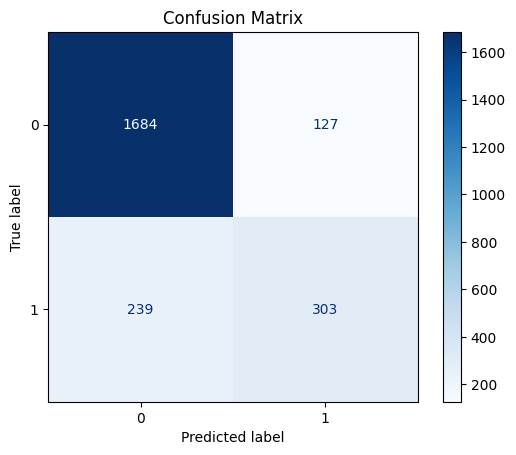

ROC AUC: 0.8916

Calculating feature importance...


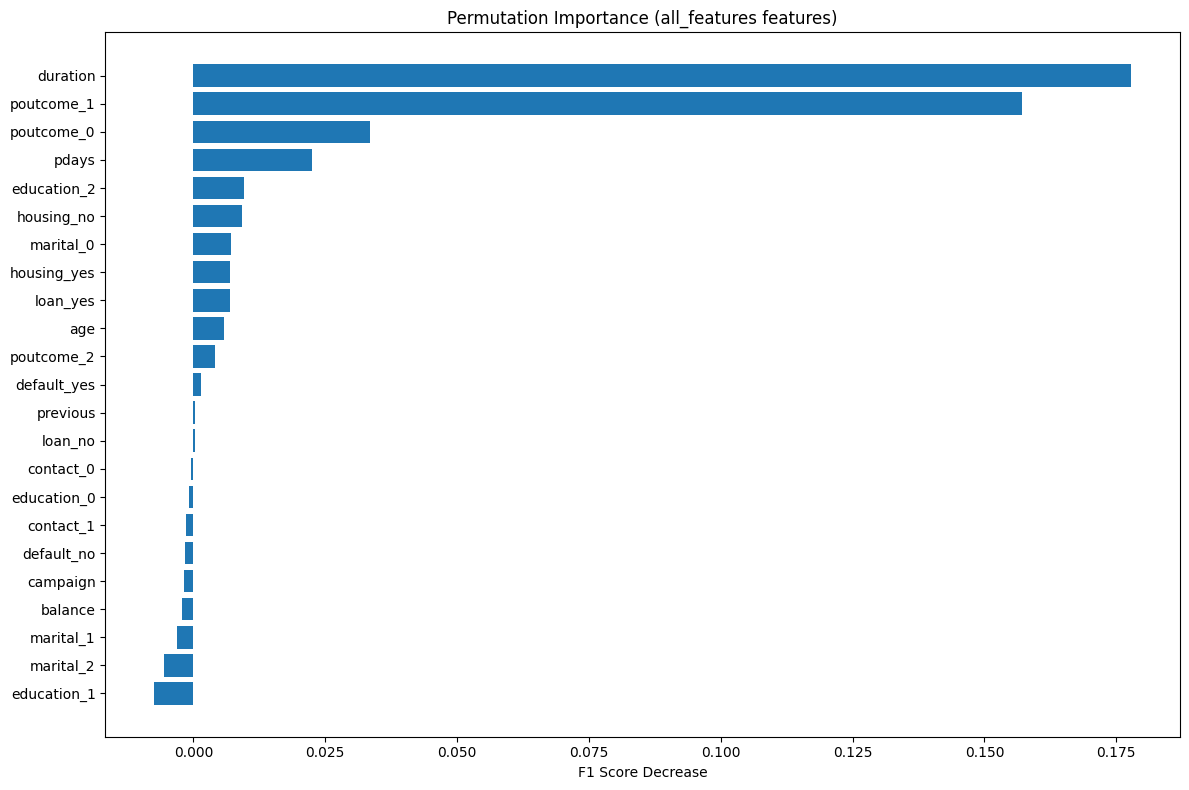


Model Comparison:
       Model  Accuracy  Precision    Recall        F1   ROC AUC
0   Baseline  0.769656        NaN       NaN       NaN       NaN
1  Final ANN  0.844454   0.704651  0.559041  0.623457  0.891612


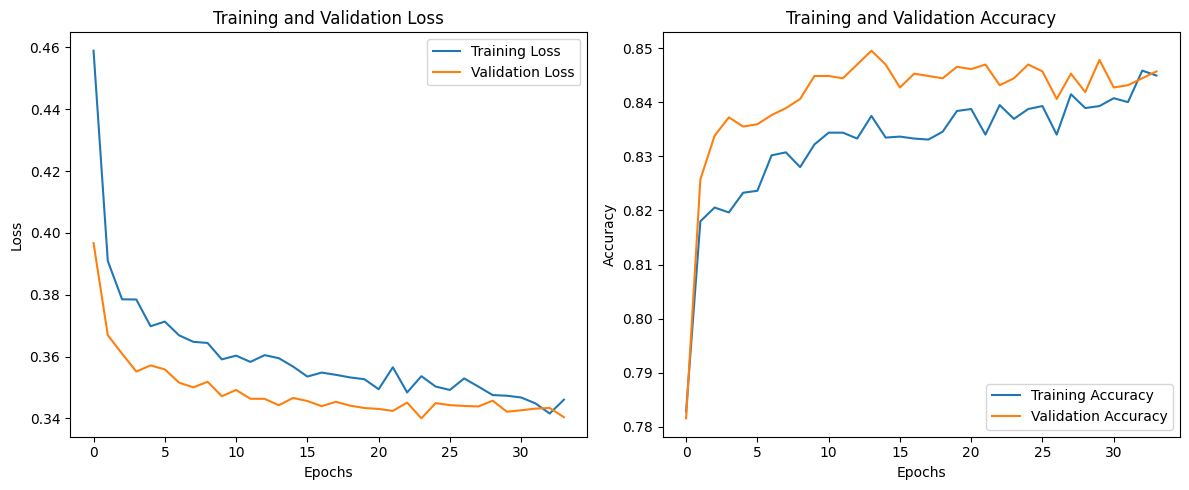

In [5]:
# ========================
# Section 5: Evaluation and Visualization
# ========================
print("\nEvaluating final model...")

# Generate predictions
y_pred = (final_model.predict(X_test_prep) > 0.5).astype("int32").flatten()
y_proba = final_model.predict(X_test_prep).flatten()

# Evaluate performance
print("\n" + "="*50)
print(f"Best Configuration: {best_set} features with {best_arch} architecture")
print("="*50)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ========================
# Feature Importance Analysis
# ========================
print("\nCalculating feature importance...")

# Create a custom scoring function that uses class predictions
from sklearn.metrics import make_scorer, f1_score

def f1_scorer(y_true, y_pred):
    """Custom scorer that converts probabilities to class predictions"""
    # Convert probabilities to binary predictions
    y_pred_binary = (y_pred > 0.5).astype("int32")
    return f1_score(y_true, y_pred_binary)

# Create a custom estimator wrapper for TensorFlow model
class TFModelWrapper:
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y):
        # Dummy fit method - the model is already trained
        return self
    
    def predict(self, X):
        # Get probabilities and convert to binary predictions
        probas = self.model.predict(X, verbose=0)
        return (probas > 0.5).astype(int)
    
    def predict_proba(self, X):
        # Return probabilities as a 2D array
        probas = self.model.predict(X, verbose=0)
        # Convert to 2D array: [1-p, p] for each sample
        return np.column_stack([1-probas, probas])

# Wrap the TensorFlow model
wrapped_model = TFModelWrapper(final_model)

# Use the standard f1_score with the wrapped model
scorer = make_scorer(f1_score)

# Calculate permutation importance
result = permutation_importance(
    wrapped_model, 
    X_test_prep, 
    y_test,
    scoring=scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Get feature names
if 'num' in preprocessor.named_transformers_:
    num_features = preprocessor.transformers_[0][2]
else:
    num_features = []
    
if 'cat' in preprocessor.named_transformers_:
    cat_encoder = preprocessor.named_transformers_['cat']
    # Get original categorical features in this set
    cat_in_set = [col for col in categorical_cols if col in feature_sets[best_set]]
    cat_features = cat_encoder.get_feature_names_out(cat_in_set)
else:
    cat_features = []

all_features = list(num_features) + list(cat_features)

# Plot importance
plt.figure(figsize=(12, 8))
importances_mean = result.importances_mean
sorted_idx = importances_mean.argsort()
plt.barh(np.array(all_features)[sorted_idx], importances_mean[sorted_idx])
plt.title(f"Permutation Importance ({best_set} features)")
plt.xlabel("F1 Score Decrease")
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# ========================
# Results Comparison Table
# ========================
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_prep, y_train)
baseline_acc = dummy.score(X_test_prep, y_test)

comparison = pd.DataFrame({
    'Model': ['Baseline', 'Final ANN'],
    'Accuracy': [baseline_acc, accuracy_score(y_test, y_pred)],
    'Precision': [np.nan, precision_score(y_test, y_pred)],
    'Recall': [np.nan, recall_score(y_test, y_pred)],
    'F1': [np.nan, f1_score(y_test, y_pred)],
    'ROC AUC': [np.nan, roc_auc_score(y_test, y_proba)]
})

print("\nModel Comparison:")
print(comparison)
comparison.to_csv('model_comparison.csv', index=False)

# Plot training history for best model
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()